# 🌸 Task 1: Iris Dataset - Exploratory Data Analysis
## DevelopersHub Corporation | AI/ML Internship
### Objective: Load, explore and visualize the Iris dataset


In [16]:
# ── Importing Required Libraries ──────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
import warnings
warnings.filterwarnings('ignore')

# ── Plot Style ────────────────────────────────────────────
plt.style.use('dark_background')
sns.set_palette("husl")

print("✅ All Libraries Imported Successfully!")
print(f"   Pandas  version: {pd.__version__}")
print(f"   Numpy   version: {np.__version__}")
print(f"   Seaborn version: {sns.__version__}")

✅ All Libraries Imported Successfully!
   Pandas  version: 3.0.3
   Numpy   version: 2.4.6
   Seaborn version: 0.13.2


In [17]:
# ── Loading Iris Dataset ──────────────────────────────────
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

print("✅ Dataset Loaded Successfully!")
print(f"\n📊 Dataset Shape: {df.shape}")
print(f"🌸 Species: {df['species'].unique()}")
print(f"\n🔍 First 5 Rows:")
df.head()

✅ Dataset Loaded Successfully!

📊 Dataset Shape: (150, 5)
🌸 Species: ['setosa', 'versicolor', 'virginica']
Categories (3, str): ['setosa', 'versicolor', 'virginica']

🔍 First 5 Rows:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [18]:
# ── Dataset Information & Statistics ─────────────────────
print("=" * 55)
print("         📋 DATASET INFORMATION")
print("=" * 55)
print(df.info())

print("\n" + "=" * 55)
print("         📊 STATISTICAL SUMMARY")
print("=" * 55)
df.describe().round(2)

         📋 DATASET INFORMATION
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   sepal length (cm)  150 non-null    float64 
 1   sepal width (cm)   150 non-null    float64 
 2   petal length (cm)  150 non-null    float64 
 3   petal width (cm)   150 non-null    float64 
 4   species            150 non-null    category
dtypes: category(1), float64(4)
memory usage: 5.0 KB
None

         📊 STATISTICAL SUMMARY


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


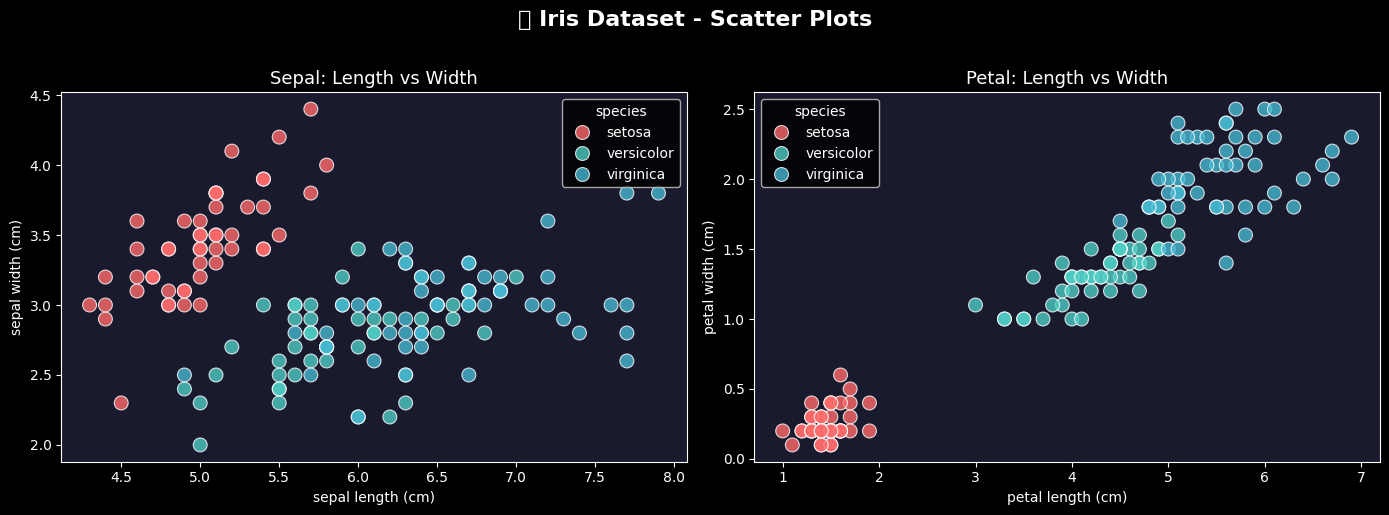

✅ Scatter Plot saved!


In [19]:
# ── Scatter Plot ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('🌸 Iris Dataset - Scatter Plots', 
             fontsize=16, fontweight='bold', color='white', y=1.02)

# Plot 1: Sepal
sns.scatterplot(ax=axes[0], data=df, 
                x='sepal length (cm)', y='sepal width (cm)',
                hue='species', palette=['#ff6b6b','#4ecdc4','#45b7d1'],
                s=100, alpha=0.8)
axes[0].set_title('Sepal: Length vs Width', color='white', fontsize=13)
axes[0].set_facecolor('#1a1a2e')

# Plot 2: Petal
sns.scatterplot(ax=axes[1], data=df,
                x='petal length (cm)', y='petal width (cm)',
                hue='species', palette=['#ff6b6b','#4ecdc4','#45b7d1'],
                s=100, alpha=0.8)
axes[1].set_title('Petal: Length vs Width', color='white', fontsize=13)
axes[1].set_facecolor('#1a1a2e')

plt.tight_layout()
plt.savefig('scatter_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Scatter Plot saved!")

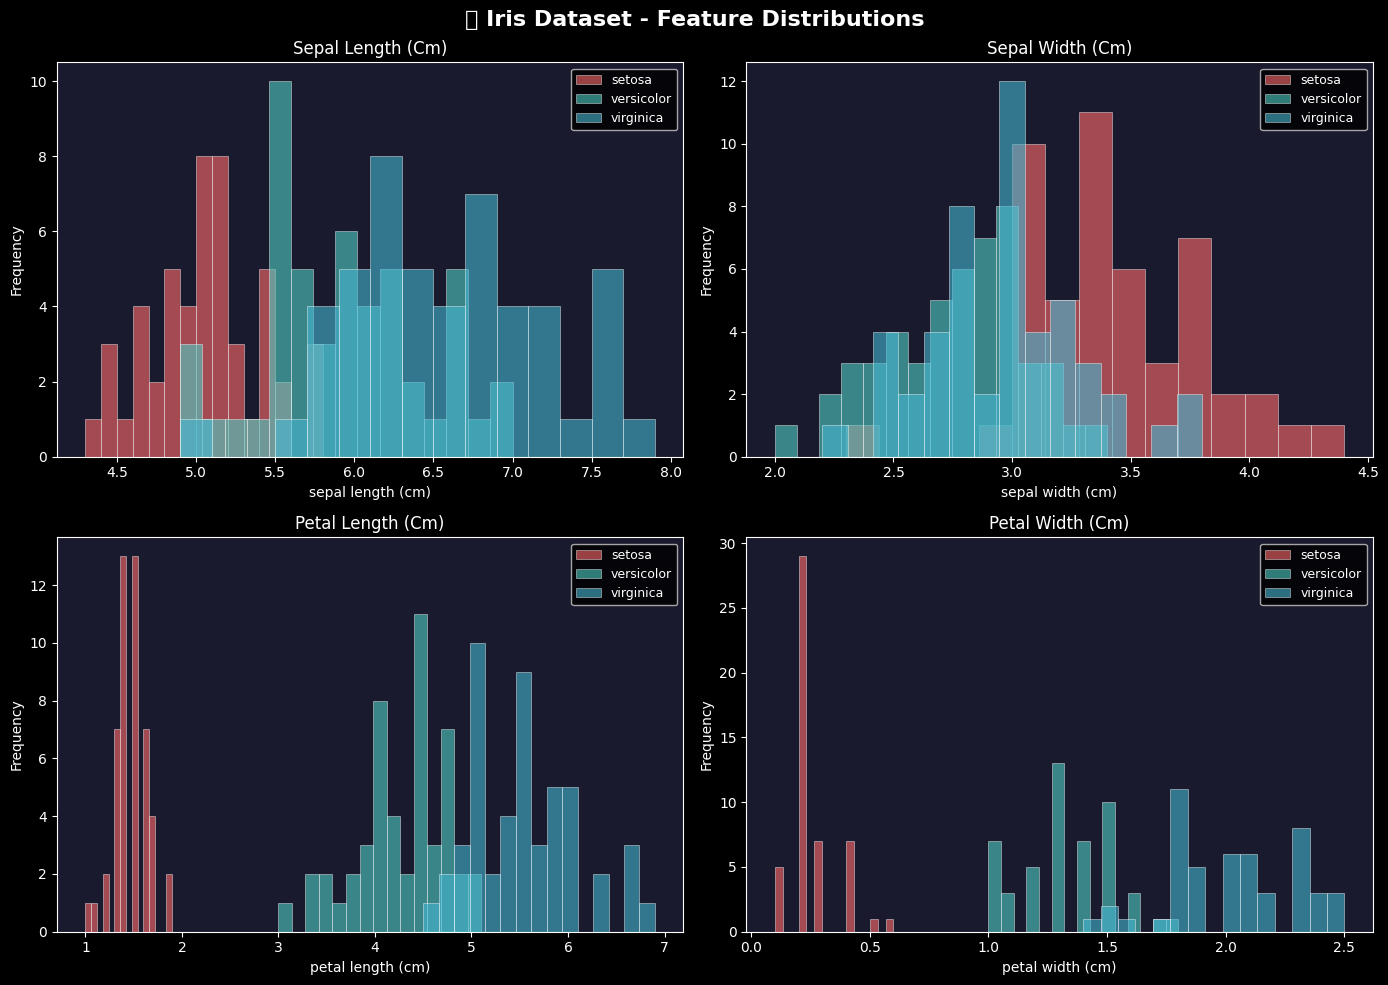

✅ Histogram saved!


In [20]:
# ── Histogram ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('🌸 Iris Dataset - Feature Distributions',
             fontsize=16, fontweight='bold', color='white')

colors = ['#ff6b6b', '#4ecdc4', '#45b7d1', '#96ceb4']
features = df.columns[:-1]

for i, (ax, feature, color) in enumerate(zip(axes.flatten(), features, colors)):
    for species, grp_color in zip(df['species'].unique(), 
                                   ['#ff6b6b','#4ecdc4','#45b7d1']):
        subset = df[df['species'] == species]
        ax.hist(subset[feature], alpha=0.6, label=species, 
                bins=15, color=grp_color, edgecolor='white', linewidth=0.5)
    ax.set_title(feature.title(), color='white', fontsize=12)
    ax.set_facecolor('#1a1a2e')
    ax.legend(fontsize=9)
    ax.set_xlabel(feature, color='white')
    ax.set_ylabel('Frequency', color='white')

plt.tight_layout()
plt.savefig('histogram.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Histogram saved!")

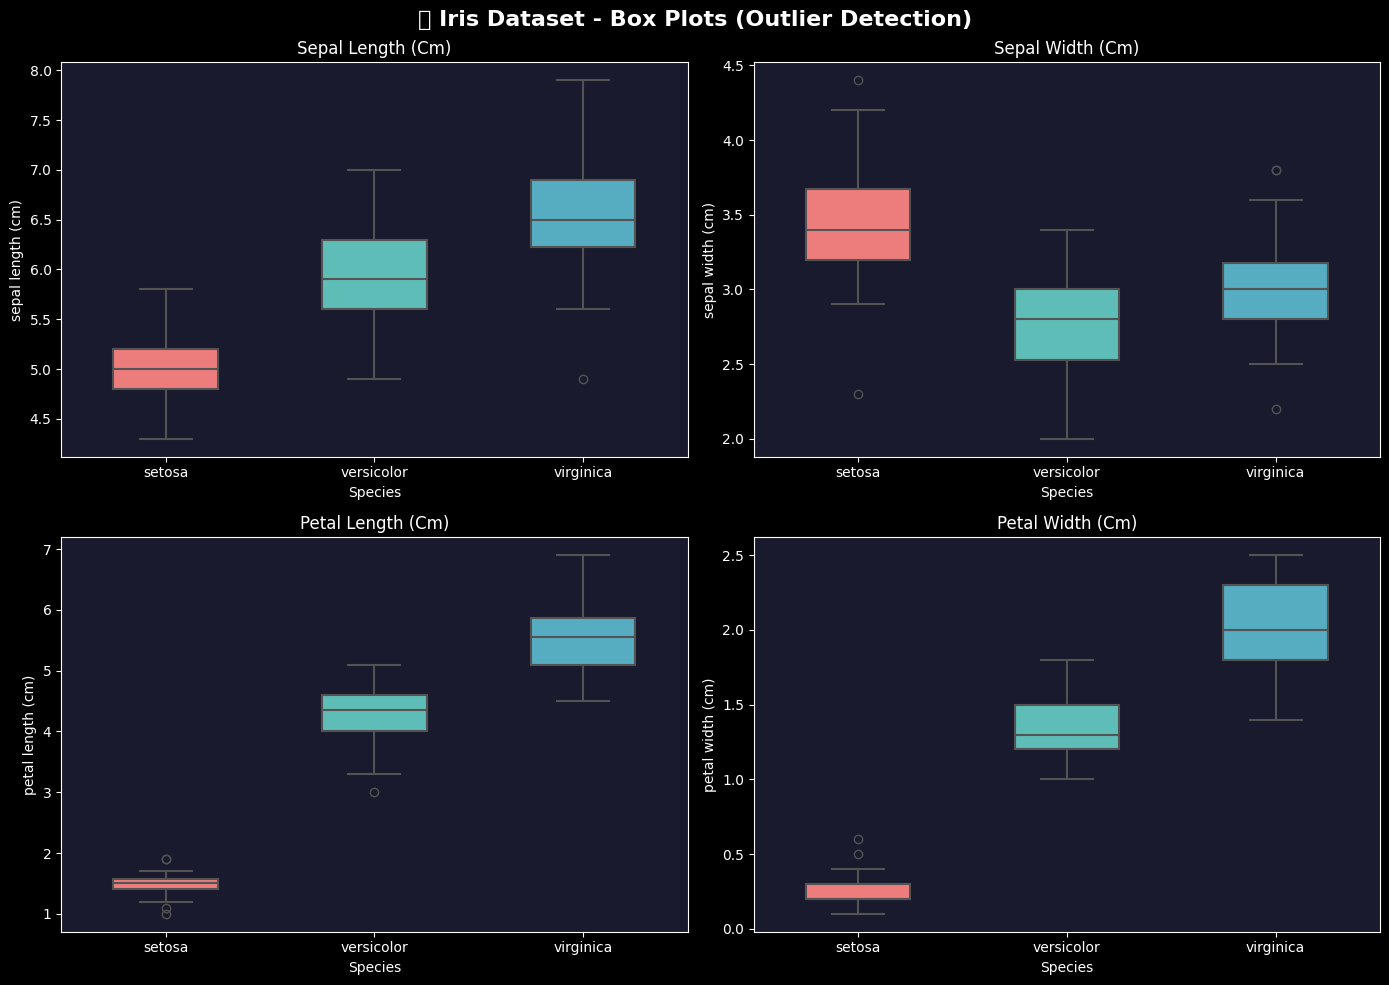

✅ Box Plot saved!


In [21]:
# ── Box Plot ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('🌸 Iris Dataset - Box Plots (Outlier Detection)',
             fontsize=16, fontweight='bold', color='white')

features = df.columns[:-1]
palette  = ['#ff6b6b','#4ecdc4','#45b7d1']

for ax, feature in zip(axes.flatten(), features):
    sns.boxplot(ax=ax, data=df, x='species', y=feature,
                palette=palette, width=0.5,
                linewidth=1.5, flierprops=dict(
                    marker='o', color='white', markersize=6))
    ax.set_title(feature.title(), color='white', fontsize=12)
    ax.set_facecolor('#1a1a2e')
    ax.set_xlabel('Species', color='white')
    ax.set_ylabel(feature, color='white')
    ax.tick_params(colors='white')

plt.tight_layout()
plt.savefig('boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Box Plot saved!")

In [22]:
# ── Key Findings & Conclusions ────────────────────────────
print("=" * 55)
print("      🔍 KEY FINDINGS & CONCLUSIONS")
print("=" * 55)

print("""
📌 FINDING 1 — Scatter Plot:
   • Setosa is clearly SEPARATED from others
   • Versicolor & Virginica slightly overlap
   • Petal features are better for classification

📌 FINDING 2 — Histogram:
   • Setosa has SMALLEST petal size
   • Virginica has LARGEST petal size
   • Sepal width is normally distributed

📌 FINDING 3 — Box Plot (Outliers):
   • Sepal width has most outliers
   • Petal features have very few outliers
   • Virginica has most variation in sepal length

✅ CONCLUSION:
   Petal Length & Petal Width are the MOST
   important features to classify Iris species!
   This dataset is perfect for ML classification.
""")

print("=" * 55)
print("  ✅ Task 1 Complete! | DevelopersHub Internship")
print("=" * 55)

      🔍 KEY FINDINGS & CONCLUSIONS

📌 FINDING 1 — Scatter Plot:
   • Setosa is clearly SEPARATED from others
   • Versicolor & Virginica slightly overlap
   • Petal features are better for classification

📌 FINDING 2 — Histogram:
   • Setosa has SMALLEST petal size
   • Virginica has LARGEST petal size
   • Sepal width is normally distributed

📌 FINDING 3 — Box Plot (Outliers):
   • Sepal width has most outliers
   • Petal features have very few outliers
   • Virginica has most variation in sepal length

✅ CONCLUSION:
   Petal Length & Petal Width are the MOST
   important features to classify Iris species!
   This dataset is perfect for ML classification.

  ✅ Task 1 Complete! | DevelopersHub Internship
